# IMF Port Data — Country Coverage & Port Selection Threshold Analysis

**Section 1** compares which countries appear in the IMF port dataset vs. the BACI trade data,  
using the shared ISO3 country codes as the join key.

**Section 2** analyses how a coverage threshold affects the number of ports selected per country,  
to inform the choice of threshold for `network_extraction.ipynb`.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Paths ───────────────────────────────────────────────────────────────────
IMF_PORT_PATH      = '../../data/port_data_imf.csv'
BACI_CODES_PATH    = '../../data/raw_trade_data/BACI_country_codes.csv'
TRADE_MATRIX_PATH  = '../../data/all_trade_matrices/trade_matrix_all_transport_modes_TOTAL.csv'

In [14]:
# ── Load data ────────────────────────────────────────────────────────────────
imf = pd.read_csv(IMF_PORT_PATH)
print(f'IMF ports: {len(imf):,} rows, {imf["ISO3"].nunique()} unique ISO3 codes')
print(f'Columns: {imf.columns.tolist()}')
print()

# BACI country codes: iso3 ↔ trade-data country name
baci_codes = pd.read_csv(BACI_CODES_PATH)
iso3_to_baci = dict(zip(baci_codes['country_iso3'], baci_codes['country_name']))
print(f'BACI codes: {len(baci_codes)} countries')

# Trade matrix column headers = the canonical country names used throughout
trade_matrix = pd.read_csv(TRADE_MATRIX_PATH, nrows=0)
trade_countries = set(trade_matrix.columns) - {'World'}
print(f'Trade matrix: {len(trade_countries)} countries')

IMF ports: 2,033 rows, 180 unique ISO3 codes
Columns: ['X', 'Y', 'portid', 'portname', 'country', 'ISO3', 'continent', 'fullname', 'lat', 'lon', 'vessel_count_total', 'vessel_count_container', 'vessel_count_dry_bulk', 'vessel_count_general_cargo', 'vessel_count_RoRo', 'vessel_count_tanker', 'industry_top1', 'industry_top2', 'industry_top3', 'share_country_maritime_import', 'share_country_maritime_export', 'LOCODE', 'pageid', 'countrynoaccents', 'ObjectId']

BACI codes: 230 countries
Trade matrix: 227 countries


---
## Section 1 — Country Coverage Comparison

ISO3 codes in the IMF data are matched to BACI `country_name` values via `BACI_country_codes.csv`.  
This avoids all the manual name-mapping needed with the old WPI approach.

In [15]:
# Map each IMF ISO3 code to its BACI country name.
# BACI uses 'S19' (not TWN) as its internal code for Taiwan, so add the bridge manually.
iso3_to_baci = dict(zip(baci_codes['country_iso3'], baci_codes['country_name']))
iso3_to_baci['TWN'] = iso3_to_baci['S19']   # Taiwan → 'Other Asia, nes'

unresolved = sorted([iso3 for iso3 in imf['ISO3'].unique()
                     if iso3 not in iso3_to_baci])
print(f'IMF ISO3 codes still unresolved ({len(unresolved)}): {unresolved}')
print('  (Overseas territories not listed as independent countries in BACI.)')
print()

# Attach BACI name to every IMF row once, then reuse throughout
imf['baci_name'] = imf['ISO3'].map(iso3_to_baci)

# Set of BACI country names represented by the IMF port data
imf_baci_names = set(imf['baci_name'].dropna().unique())

in_both       = sorted(trade_countries & imf_baci_names)
in_trade_only = sorted(trade_countries - imf_baci_names)
in_imf_only   = sorted(imf_baci_names  - trade_countries)

print(f'Countries in BOTH trade data and IMF ports:       {len(in_both)}')
print(f'Countries in trade data ONLY (no IMF port):      {len(in_trade_only)}')
print(f'Countries in IMF ports ONLY (not in trade data): {len(in_imf_only)}')

IMF ISO3 codes still unresolved (8): ['FRO', 'GLP', 'GUF', 'MAF', 'MTQ', 'PRI', 'REU', 'VIR']
  (Overseas territories not listed as independent countries in BACI.)

Countries in BOTH trade data and IMF ports:       171
Countries in trade data ONLY (no IMF port):      56
Countries in IMF ports ONLY (not in trade data): 1


In [16]:
print('=== Trade-data countries with NO port in the IMF dataset ===')
print('(Likely landlocked, very small territories, or uses a different ISO3 code)')
print()
for c in in_trade_only:
    print(f'  - {c}')

=== Trade-data countries with NO port in the IMF dataset ===
(Likely landlocked, very small territories, or uses a different ISO3 code)

  - Afghanistan
  - Andorra
  - Armenia
  - Austria
  - Belarus
  - Bermuda
  - Bhutan
  - Bolivia (Plurinational State of)
  - Bosnia Herzegovina
  - Botswana
  - Br. Indian Ocean Terr.
  - Burkina Faso
  - Burundi
  - Central African Rep.
  - Chad
  - Christmas Isds
  - Cocos Isds
  - Czechia
  - Dem. People's Rep. of Korea
  - Eswatini
  - Ethiopia
  - Falkland Isds (Malvinas)
  - Fr. South Antarctic Terr.
  - Greenland
  - Hungary
  - Kyrgyzstan
  - Lao People's Dem. Rep.
  - Lesotho
  - Luxembourg
  - Malawi
  - Mali
  - Mongolia
  - Nepal
  - Niger
  - Niue
  - Norfolk Isds
  - North Macedonia
  - Paraguay
  - Pitcairn
  - Rwanda
  - Saint Helena
  - Saint Pierre and Miquelon
  - San Marino
  - Serbia
  - Slovakia
  - South Sudan
  - State of Palestine
  - Switzerland
  - Tajikistan
  - Tokelau
  - Uganda
  - Unnamed: 0
  - Uzbekistan
  - Wallis

In [17]:
print('=== IMF countries NOT found in trade data ===')
print('(Historic BACI entities that no longer appear as columns in the trade matrix)')
print()
for c in in_imf_only:
    print(f'  - {c}')

print()
print('=== IMF ISO3 codes with no BACI match ===')
print('(Overseas territories — ports exist but country not in BACI_country_codes.csv)')
print()
for iso3 in unresolved:
    country_name = imf[imf['ISO3'] == iso3]['country'].iloc[0]
    n_ports = (imf['ISO3'] == iso3).sum()
    print(f'  - {iso3} ({country_name}): {n_ports} port(s)')

=== IMF countries NOT found in trade data ===
(Historic BACI entities that no longer appear as columns in the trade matrix)

  - Mayotte (Overseas France)

=== IMF ISO3 codes with no BACI match ===
(Overseas territories — ports exist but country not in BACI_country_codes.csv)

  - FRO (Faroe Islands): 2 port(s)
  - GLP (Guadeloupe): 2 port(s)
  - GUF (French Guiana): 2 port(s)
  - MAF (Saint Martin): 1 port(s)
  - MTQ (Martinique): 1 port(s)
  - PRI (Puerto Rico): 4 port(s)
  - REU (Réunion): 1 port(s)
  - VIR (United States Virgin Islands): 3 port(s)


In [18]:
# Filter to ports whose country appears in the trade data
imf_in_trade = imf[imf['baci_name'].isin(trade_countries)].copy()
imf_in_trade['combined'] = (imf_in_trade['share_country_maritime_import']
                             + imf_in_trade['share_country_maritime_export'])

summary = (
    imf_in_trade
    .groupby('baci_name')
    .agg(
        n_ports      = ('portid', 'count'),
        total_import = ('share_country_maritime_import', 'sum'),
        total_export = ('share_country_maritime_export', 'sum'),
        top_combined = ('combined', 'max'),
    )
    .reset_index()
    .rename(columns={'baci_name': 'country'})
    .sort_values('n_ports', ascending=False)
)

print(f'Countries with ports in trade data: {len(summary)}')
print(f'Total ports available:              {summary.n_ports.sum():,}')
print(f'Countries with only 1 port:         {(summary.n_ports == 1).sum()}')
print(f'Countries with > 20 ports:          {(summary.n_ports > 20).sum()}')
print()
print('Top 20 countries by number of ports:')
print(summary.head(20).to_string(index=False))

Countries with ports in trade data: 171
Total ports available:              2,016
Countries with only 1 port:         35
Countries with > 20 ports:          25

Top 20 countries by number of ports:
           country  n_ports  total_import  total_export  top_combined
             Japan      146         99.94         99.96         14.62
               USA      117        100.04         99.99         27.61
             China      109         99.97        100.00         18.95
            Brazil      103         99.98         99.99         28.32
         Indonesia      101         99.97        100.03         22.01
    United Kingdom       79        100.02        100.01         22.55
         Australia       57         99.98        100.00         38.97
            Norway       53         99.99        100.04         59.05
Russian Federation       46         99.97         99.98         35.42
             Italy       45        100.02         99.98         35.43
            Canada       42     

---
## Section 2 — Threshold-Based Port Selection

For each country, ports are ranked by their combined share  
(`share_country_maritime_import + share_country_maritime_export`) and added greedily  
until **both** the cumulative import share and cumulative export share independently  
reach the threshold.

Each country always contributes at least 1 port (its largest).  
The analysis below sweeps the threshold from 0 % to 100 % to show  
how the total port count responds.

In [19]:
def select_ports(df, threshold):
    """
    For each country (grouped by ISO3), greedily add ports in descending order
    of (import_share + export_share) until BOTH cumulative import share and
    cumulative export share >= threshold.  Always adds at least 1 port.

    Returns a DataFrame of selected ports.
    """
    selected = []
    for iso3, group in df.groupby('ISO3'):
        group = group.copy()
        group['combined'] = (group['share_country_maritime_import']
                             + group['share_country_maritime_export'])
        group = group.sort_values('combined', ascending=False)

        cum_imp = 0.0
        cum_exp = 0.0
        for _, row in group.iterrows():
            selected.append(row)
            cum_imp += row['share_country_maritime_import']
            cum_exp += row['share_country_maritime_export']
            if cum_imp >= threshold and cum_exp >= threshold:
                break

    return pd.DataFrame(selected)


# Quick sanity check at threshold=50
example = select_ports(imf_in_trade, threshold=50)
print(f'Threshold = 50% → {len(example)} ports selected across {example["ISO3"].nunique()} countries')

Threshold = 50% → 359 ports selected across 171 countries


In [20]:
# Sweep thresholds 0–100 (using only countries that appear in the trade data)
thresholds = np.arange(0, 101, 1)
port_counts = [len(select_ports(imf_in_trade, t)) for t in thresholds]

# Also record counts at a few representative thresholds for annotation
annotate_at = [50, 60, 70, 80, 90]
annotate_counts = {t: port_counts[t] for t in annotate_at}
print('Ports selected at key thresholds:')
for t, n in annotate_counts.items():
    print(f'  {t}% → {n} ports')
print(f'   0% → {port_counts[0]} ports  (1 per country, always)')
print(f' 100% → {port_counts[100]} ports (all ports)')

Ports selected at key thresholds:
  50% → 359 ports
  60% → 444 ports
  70% → 528 ports
  80% → 678 ports
  90% → 912 ports
   0% → 171 ports  (1 per country, always)
 100% → 1984 ports (all ports)


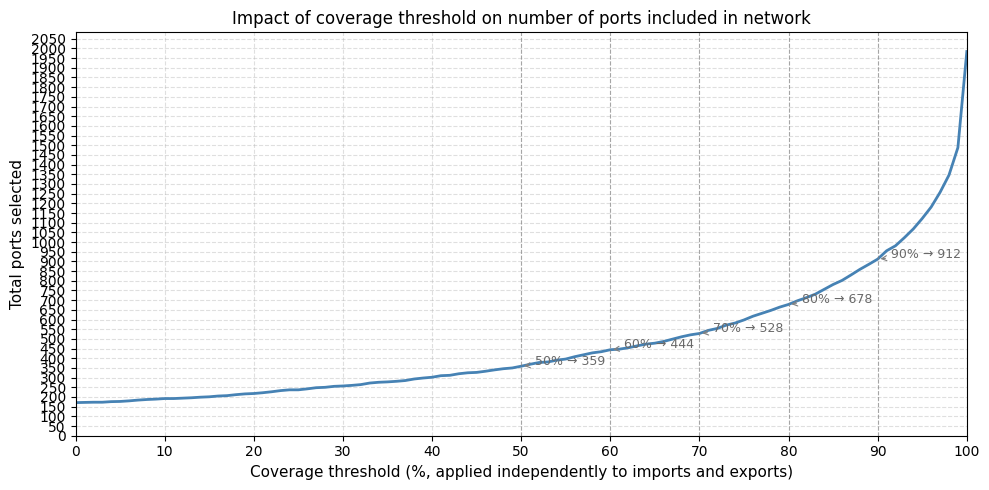

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, port_counts, color='steelblue', linewidth=2)

# Annotate key thresholds
for t in annotate_at:
    n = annotate_counts[t]
    ax.axvline(t, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.annotate(
        f'{t}% → {n}',
        xy=(t, n), xytext=(t + 1.5, n + 8),
        fontsize=9, color='dimgray',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
    )

ax.set_xlabel('Coverage threshold (%, applied independently to imports and exports)', fontsize=11)
ax.set_ylabel('Total ports selected', fontsize=11)
ax.set_title('Impact of coverage threshold on number of ports included in network', fontsize=12)
ax.set_xlim(0, 100)
ax.set_ylim(0, max(port_counts) * 1.05)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

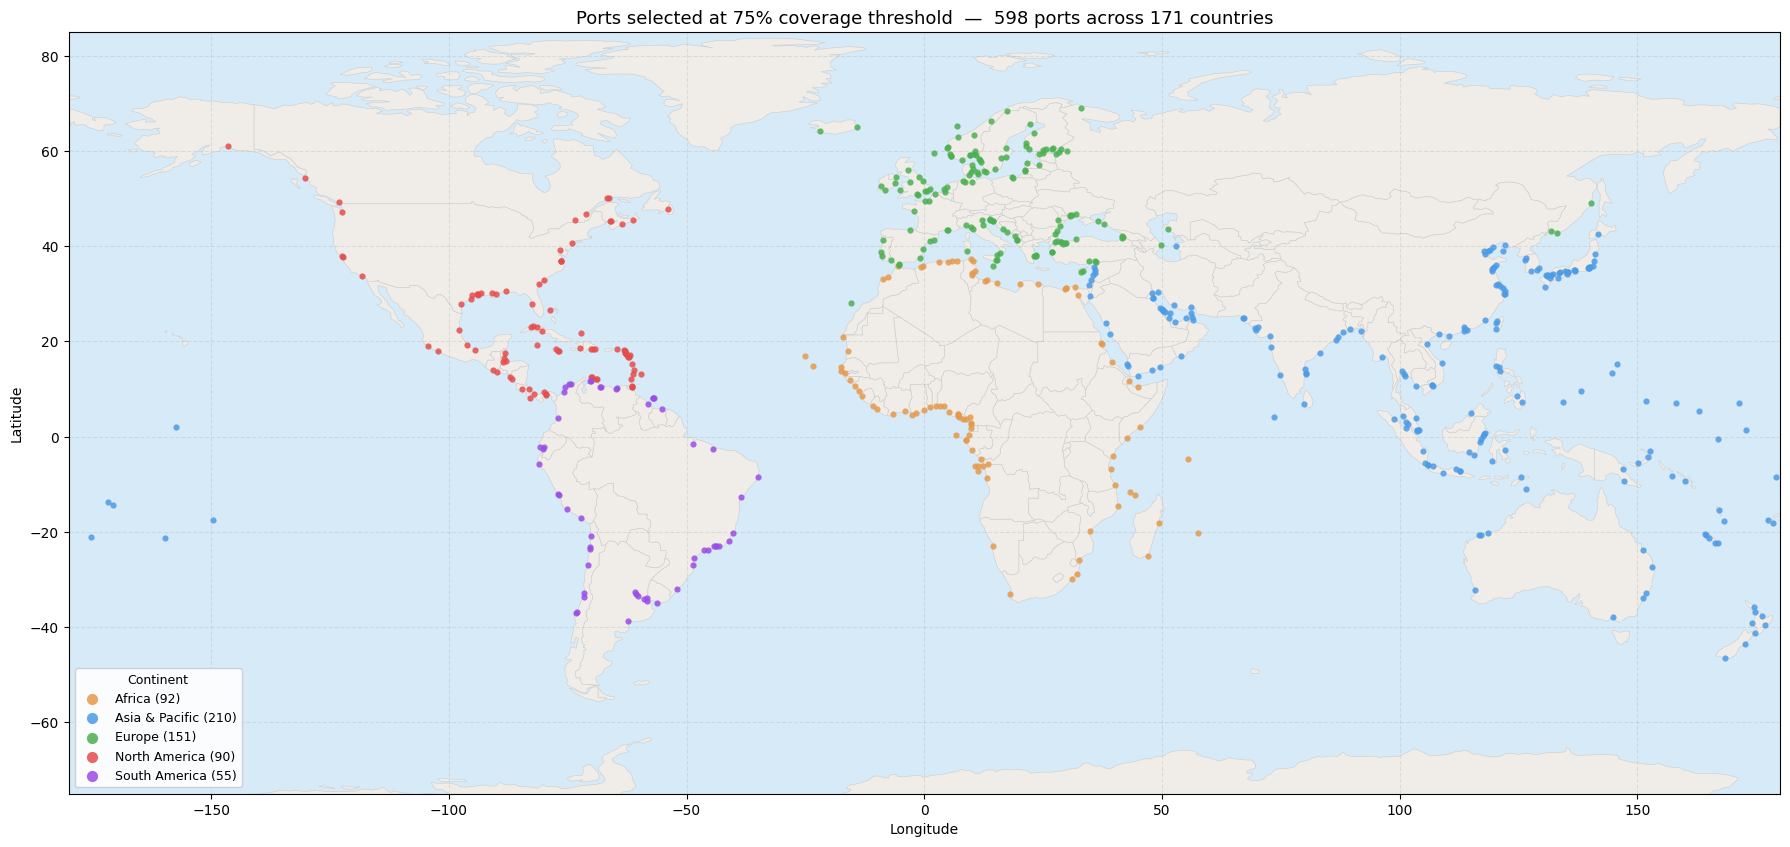

In [22]:
# ===========================================================================
# Map of ports selected at threshold = 75 %
# ===========================================================================
import geopandas as gpd

MAP_THRESHOLD = 75
selected_map = select_ports(imf_in_trade, MAP_THRESHOLD)

# Colour by continent
CONTINENT_COLORS = {
    'Africa':          '#E6994C',
    'Asia & Pacific':  '#4C9BE6',
    'Europe':          '#4CAF50',
    'North America':   '#E64C4C',
    'South America':   '#9B4CE6',
}

world = gpd.read_file('https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip')

fig, ax = plt.subplots(figsize=(18, 9))
world.plot(ax=ax, color='#F0EDE8', edgecolor='#CCCCCC', linewidth=0.4)

for continent, color in CONTINENT_COLORS.items():
    subset = selected_map[selected_map['continent'] == continent]
    ax.scatter(
        subset['lon'], subset['lat'],
        c=color, s=20, alpha=0.85, linewidths=0,
        zorder=3, label=f'{continent} ({len(subset)})',
    )

ax.set_xlim(-180, 180)
ax.set_ylim(-75, 85)
ax.set_facecolor('#D6EAF8')
ax.set_title(
    f'Ports selected at {MAP_THRESHOLD}% coverage threshold  —  {len(selected_map)} ports across '
    f'{selected_map["ISO3"].nunique()} countries',
    fontsize=13,
)
ax.legend(title='Continent', loc='lower left', fontsize=9, title_fontsize=9,
          framealpha=0.9, markerscale=1.8)
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

In [23]:
# Show which countries drive the growth at a chosen threshold — useful for calibration
INSPECT_THRESHOLD = 80

selected_80 = select_ports(imf_in_trade, INSPECT_THRESHOLD)
per_country = (
    selected_80
    .groupby(['ISO3', 'country'])
    .agg(
        n_selected   = ('portid', 'count'),
        cum_import   = ('share_country_maritime_import', 'sum'),
        cum_export   = ('share_country_maritime_export', 'sum'),
    )
    .reset_index()
    .sort_values('n_selected', ascending=False)
)

print(f'=== Threshold = {INSPECT_THRESHOLD}% — {len(selected_80)} total ports ===')
print()
print(per_country.to_string(index=False))

=== Threshold = 80% — 678 total ports ===

ISO3                            country  n_selected  cum_import  cum_export
 JPN                              Japan          34       80.36       88.57
 CHN                              China          27       80.28       90.50
 USA                      United States          27       80.88       83.74
 IDN                          Indonesia          24       80.70       90.31
 NOR                             Norway          19       81.39       90.33
 BRA                             Brazil          19       89.11       80.08
 IND                              India          14       81.01       89.79
 TUR                            Türkiye          14       80.05       85.77
 GBR                     United Kingdom          13       80.30       82.13
 SWE                             Sweden          12       82.76       83.83
 ITA                              Italy          12       81.23       89.38
 CAN                             Canada      

In [24]:
# ===========================================================================
# A* runtime estimate
# The pathfinding runs between every ordered port pair, so it scales as O(n²).
# Baseline: 432 ports took 1 h 38 m = 98 minutes.
# ===========================================================================
BASELINE_PORTS   = 432
BASELINE_MINUTES = 98   # 1 h 38 m

n_ports_75 = len(select_ports(imf_in_trade, 75))
estimated_minutes = BASELINE_MINUTES * (n_ports_75 / BASELINE_PORTS) ** 2
h = int(estimated_minutes // 60)
m = int(estimated_minutes % 60)

print(f'Baseline:  {BASELINE_PORTS} ports → {BASELINE_MINUTES} min')
print(f'At 75 %:   {n_ports_75} ports → ~{h} h {m} m  '
      f'(scaling factor {(n_ports_75/BASELINE_PORTS)**2:.2f}×)')

Baseline:  432 ports → 98 min
At 75 %:   598 ports → ~3 h 7 m  (scaling factor 1.92×)
